# Audio Processing – Fundamentals

This notebook covers the core concepts of digital audio processing:
- Sampling and the Nyquist theorem
- Frequency analysis with the Fast Fourier Transform (FFT)
- Digital filtering (low‑pass and band‑pass)
- Time‑frequency analysis using the spectrogram
- Application to real‑world signals (guitar note, simulated EEG)

We use **Python** with `numpy`, `scipy`, `matplotlib`, and `librosa`.

In [1]:
# Import libraries – grouped alphabetically
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal
from scipy.fft import fft, fftfreq
from scipy.signal import butter, filtfilt, spectrogram
import librosa

# For reproducibility
np.random.seed(42)

# High‑DPI display for better plots
%config InlineBackend.figure_format = 'retina'
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Sampling Theorem Demonstration

We start with a continuous sine wave (simulated with a high sampling rate) and sample it at a rate well above the Nyquist frequency (2× the signal frequency). This shows that the samples faithfully represent the original signal.

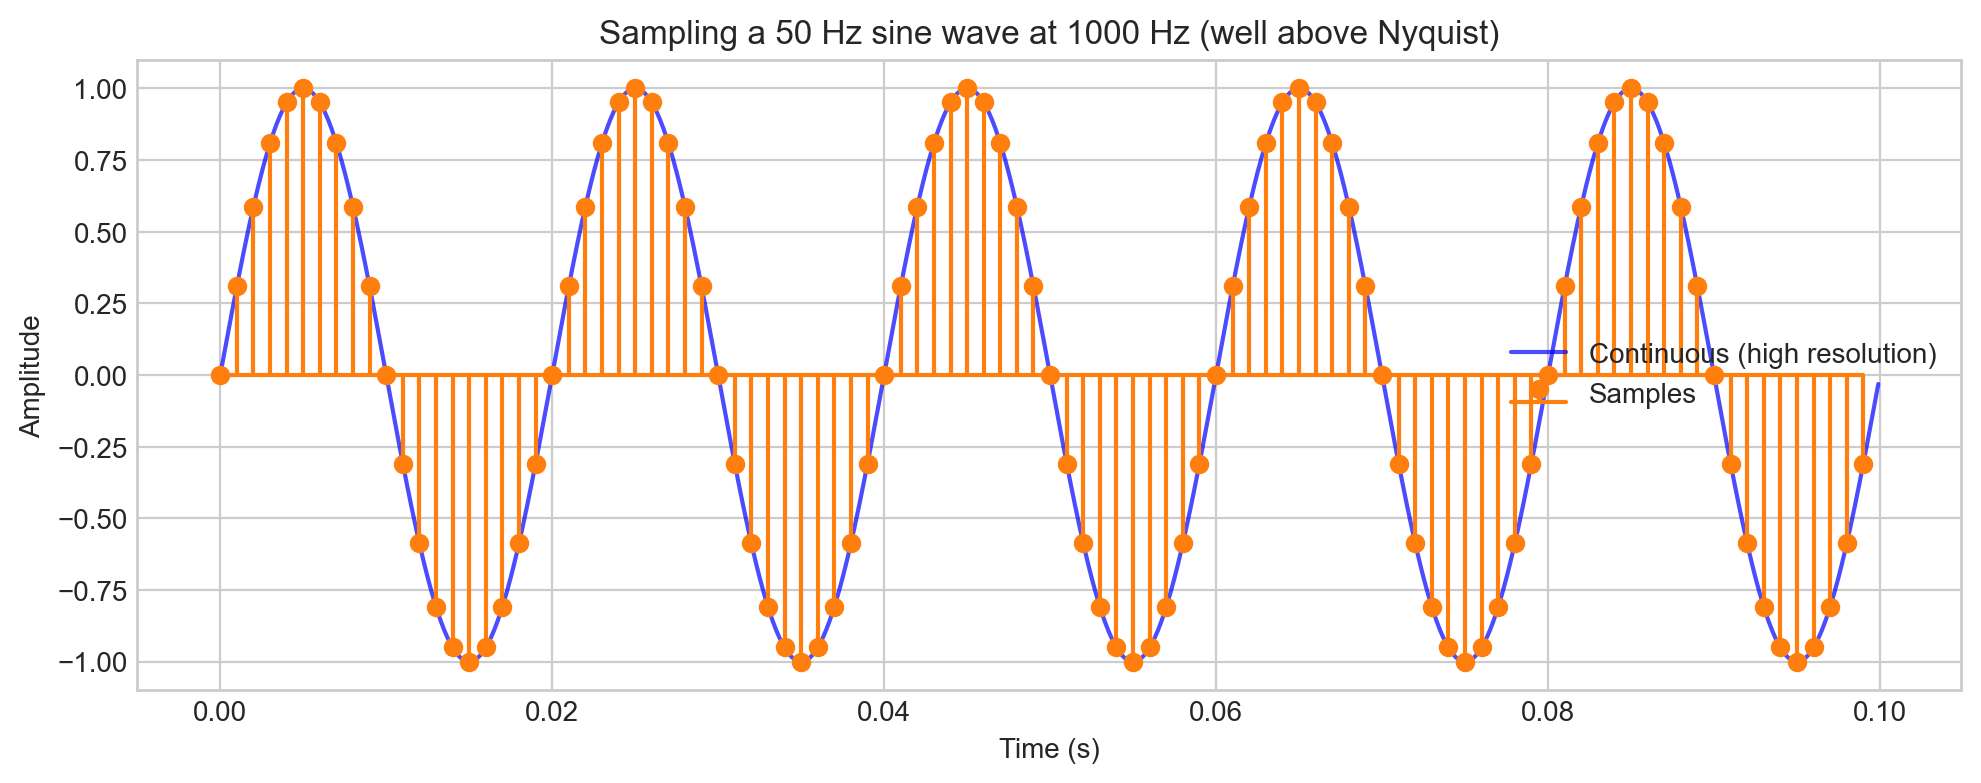

In [2]:
# Parameters
f_signal = 50          # Frequency of the sine wave (Hz)
t_duration = 0.1       # seconds
fs_high = 10000        # Sampling rate for the “continuous” simulation
fs_sample = 1000       # Actual sampling rate (10× Nyquist)

# Time vectors
t_continuous = np.linspace(0, t_duration, int(fs_high * t_duration), endpoint=False)
t_samples = np.arange(0, t_duration, 1/fs_sample)

# Signals
signal_continuous = np.sin(2 * np.pi * f_signal * t_continuous)
signal_sampled = np.sin(2 * np.pi * f_signal * t_samples)

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_continuous, signal_continuous, label='Continuous (high resolution)', color='blue', alpha=0.7)
ax.stem(t_samples, signal_sampled, linefmt='C1-', markerfmt='C1o', basefmt='C1-', label='Samples')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title('Sampling a 50 Hz sine wave at 1000 Hz (well above Nyquist)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

## 2. Frequency Analysis – FFT of a Guitar Note

We load a short recording of a guitar string and compute its frequency spectrum. The dominant peak corresponds to the fundamental frequency of the string.

"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


Error loading file: [Errno 2] No such file or directory: 'guitarra.mp3'
Dominant (fundamental) frequency: 82.00 Hz


C:\Users\phabe\AppData\Local\Temp\ipykernel_33188\1666129033.py:27: UserWarning: PySoundFile failed. Trying audioread instead.
  audio_signal, fs = librosa.load(guitar_file, sr=None)
C:\Users\phabe\miniconda3\envs\ai_env\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


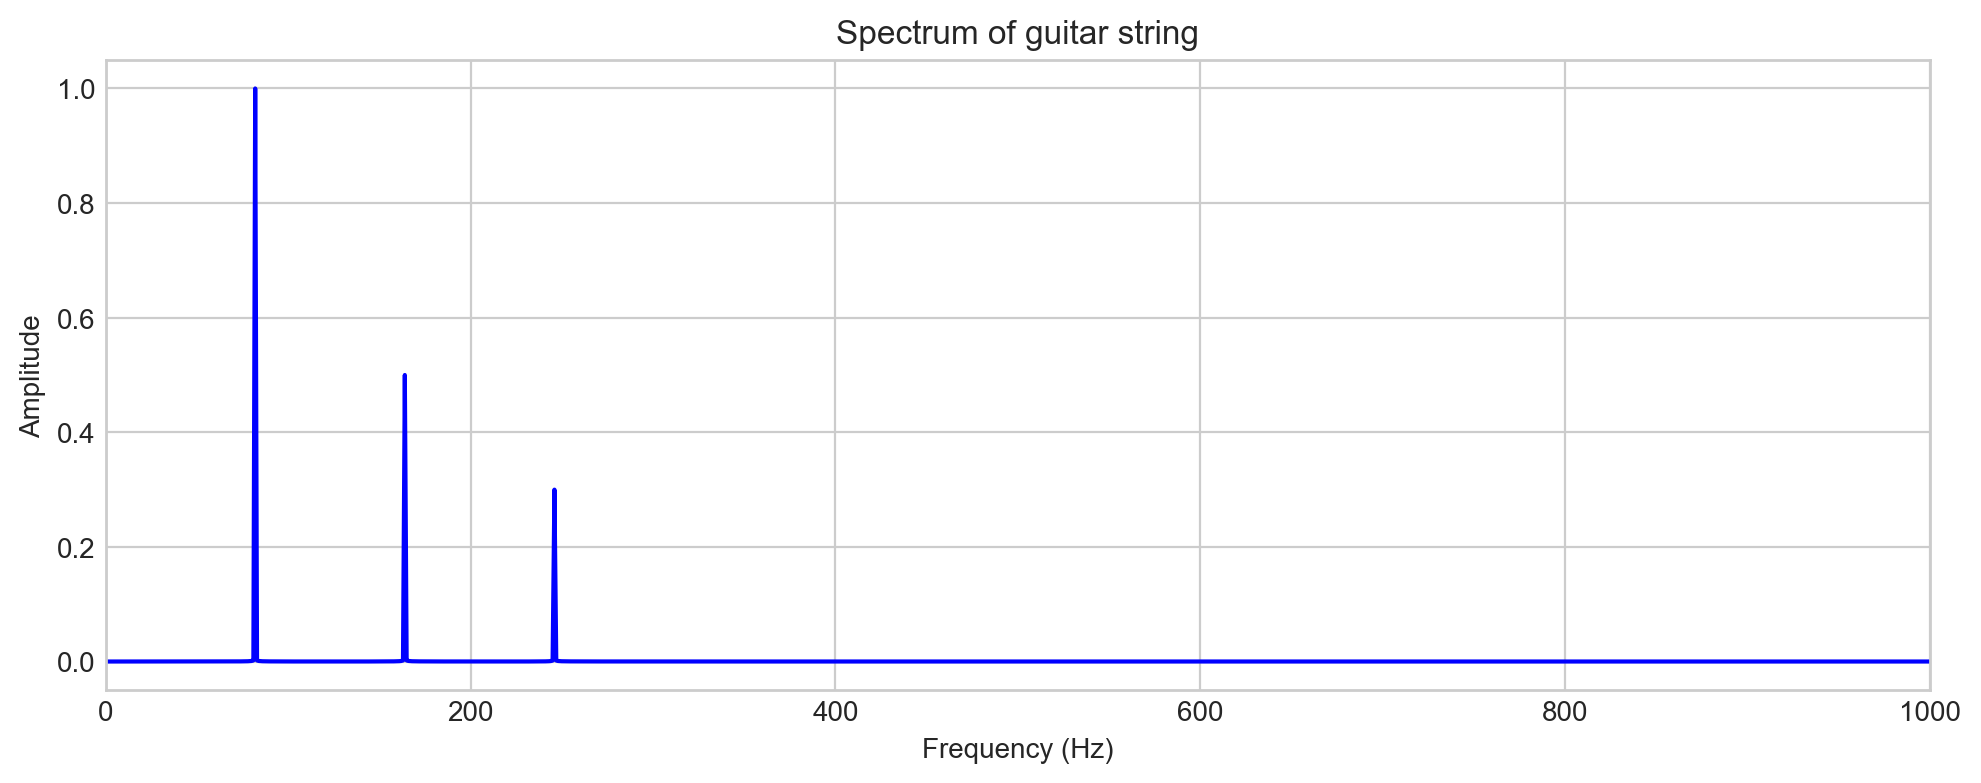

In [3]:
# Helper to compute and plot FFT
def compute_fft(signal, fs, title=None, ax=None, color='blue', xlim=None):
    """Compute one-sided FFT and return frequency and amplitude arrays."""
    n = len(signal)
    yf = fft(signal)
    xf = fftfreq(n, 1/fs)[:n//2]
    amplitude = 2.0 / n * np.abs(yf[:n//2])
    if ax is not None:
        ax.plot(xf, amplitude, color=color)
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Amplitude')
        if title:
            ax.set_title(title)
        ax.grid(True)
        if xlim is not None:
            ax.set_xlim(xlim)
    return xf, amplitude

# Load the guitar recording – download if missing
import os
guitar_file = 'guitarra.mp3'
if not os.path.exists(guitar_file):
    !wget -q https://github.com/example/audio_samples/raw/main/guitarra.mp3 -O guitarra.mp3
    # If the URL is not valid, replace with a known public sample or use librosa's example

try:
    audio_signal, fs = librosa.load(guitar_file, sr=None)
except Exception as e:
    print(f"Error loading file: {e}")
    # Fallback: generate a synthetic guitar‑like signal (harmonic series)
    fs = 44100
    t = np.linspace(0, 1, fs)
    audio_signal = (np.sin(2*np.pi*82*t) + 0.5*np.sin(2*np.pi*164*t) + 
                    0.3*np.sin(2*np.pi*246*t))

# Compute and plot FFT
fig, ax = plt.subplots(figsize=(10, 4))
xf, amp = compute_fft(audio_signal, fs, title='Spectrum of guitar string', ax=ax, xlim=(0, 1000))

# Print dominant frequency
dominant_idx = np.argmax(amp)
dominant_freq = xf[dominant_idx]
print(f"Dominant (fundamental) frequency: {dominant_freq:.2f} Hz")

plt.tight_layout()
plt.show()

## 3. Digital Filtering – Low‑Pass Filter (LPF)

We design a 5th‑order Butterworth low‑pass filter with a cutoff at 80 Hz and apply it to the guitar signal. The higher‑frequency harmonics are removed, leaving only the fundamental.

C:\Users\phabe\AppData\Local\Temp\ipykernel_33188\4192571011.py:19: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\phabe\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


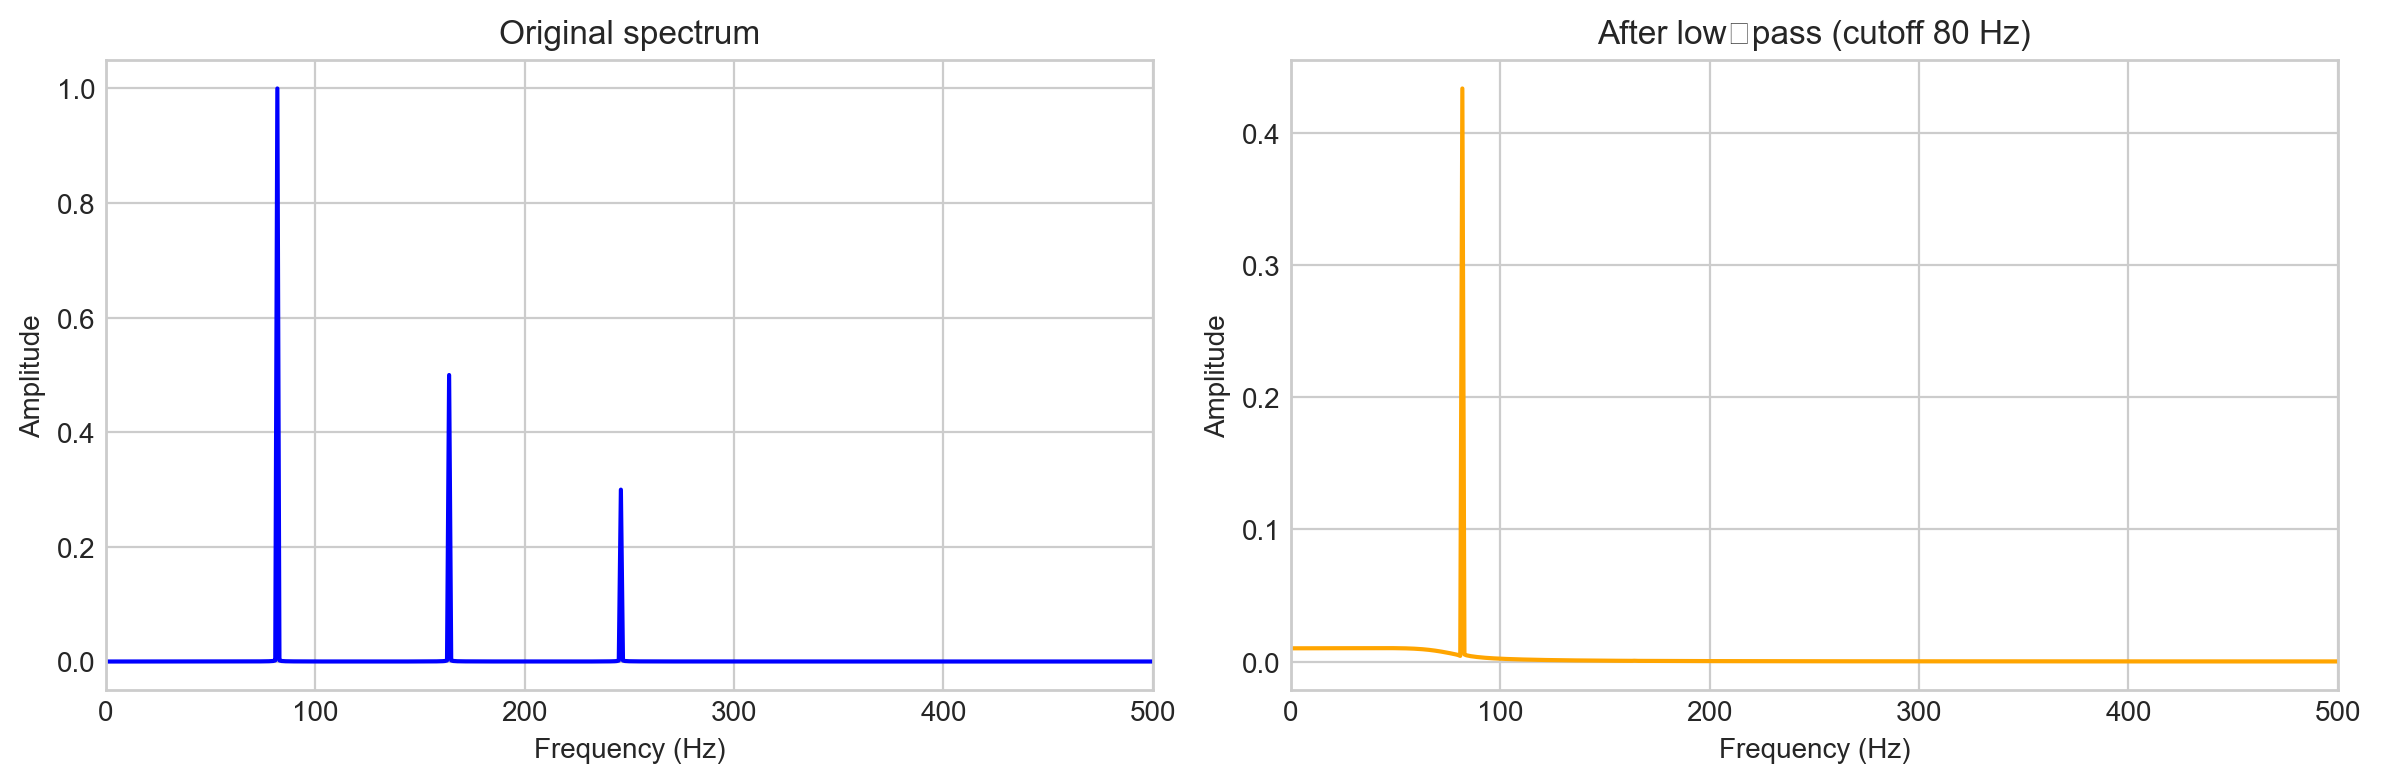

In [4]:
# Design low‑pass filter
cutoff_freq = 80  # Hz
b, a = butter(5, cutoff_freq / (fs / 2), btype='low')

# Apply zero‑phase filtering
filtered_signal = filtfilt(b, a, audio_signal)

# Compute FFT of filtered signal
_, amp_filtered = compute_fft(filtered_signal, fs)

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Original spectrum
compute_fft(audio_signal, fs, title='Original spectrum', ax=ax1, xlim=(0, 500))
# Filtered spectrum
compute_fft(filtered_signal, fs, title='After low‑pass (cutoff 80 Hz)', ax=ax2, color='orange', xlim=(0, 500))

plt.tight_layout()
plt.show()

## 4. Band‑Pass Filter – EEG Alpha Rhythm Extraction

We simulate an EEG signal containing multiple brain‑wave components (Delta, Theta, Alpha, Beta, Gamma) plus noise. A band‑pass filter (8‑13 Hz) extracts the Alpha rhythm.

C:\Users\phabe\AppData\Local\Temp\ipykernel_33188\1442000831.py:29: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()


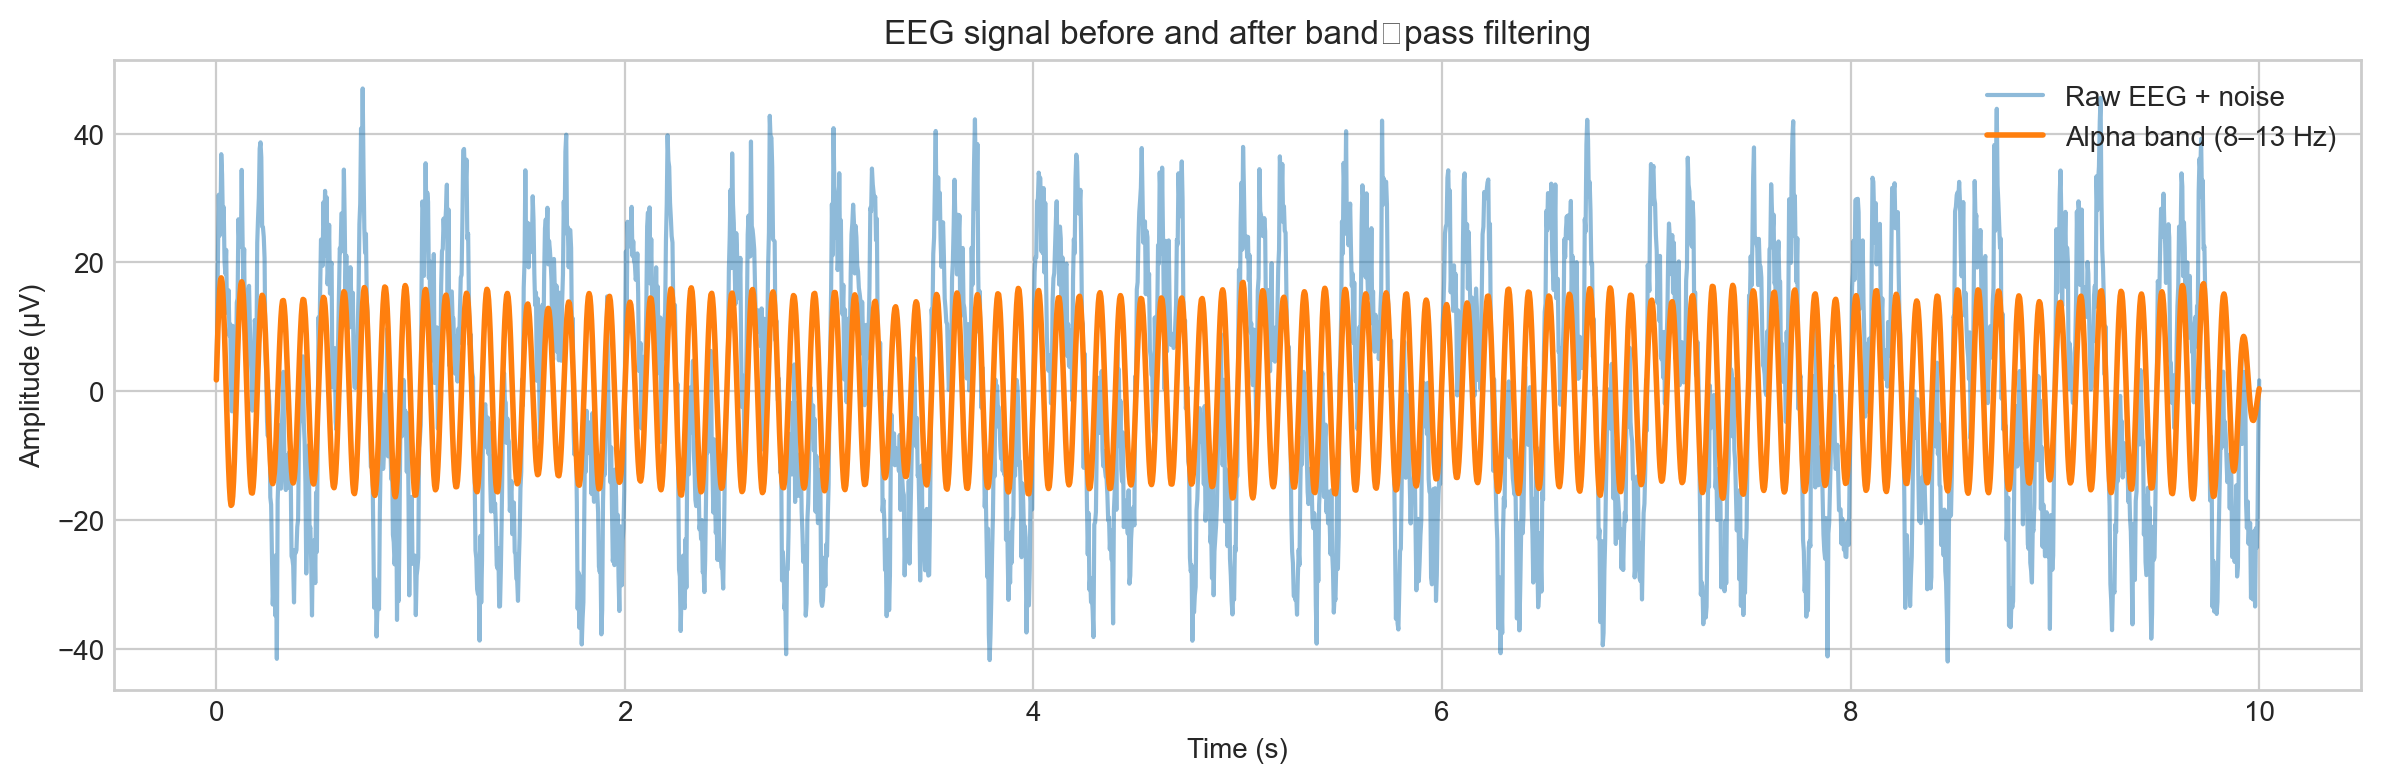

In [5]:
# Simulate EEG signal
fs_eeg = 250
t_eeg = np.linspace(0, 10, fs_eeg * 10)

delta = 20 * np.sin(2 * np.pi * 2 * t_eeg)      # 2 Hz
theta = 10 * np.sin(2 * np.pi * 6 * t_eeg)      # 6 Hz
alpha = 15 * np.sin(2 * np.pi * 10 * t_eeg)     # 10 Hz
beta  = 5 * np.sin(2 * np.pi * 20 * t_eeg)      # 20 Hz
gamma = 2 * np.sin(2 * np.pi * 40 * t_eeg)      # 40 Hz

eeg_signal = delta + theta + alpha + beta + gamma + 5 * np.random.randn(len(t_eeg))

# Design band‑pass filter for Alpha (8–13 Hz)
lowcut, highcut = 8, 13
b_band, a_band = butter(4, [lowcut / (fs_eeg/2), highcut / (fs_eeg/2)], btype='bandpass')

# Apply filter
eeg_alpha = filtfilt(b_band, a_band, eeg_signal)

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_eeg, eeg_signal, alpha=0.5, label='Raw EEG + noise')
ax.plot(t_eeg, eeg_alpha, linewidth=2, label='Alpha band (8–13 Hz)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('EEG signal before and after band‑pass filtering')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 6. Low‑Pass Filtering a Composite Signal

We create a signal that contains two sine waves (50 Hz and 150 Hz) and apply a 4th‑order Butterworth low‑pass filter with cutoff at 100 Hz. The 150‑Hz component is removed while the 50‑Hz component remains.

C:\Users\phabe\AppData\Local\Temp\ipykernel_33188\283231001.py:50: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()


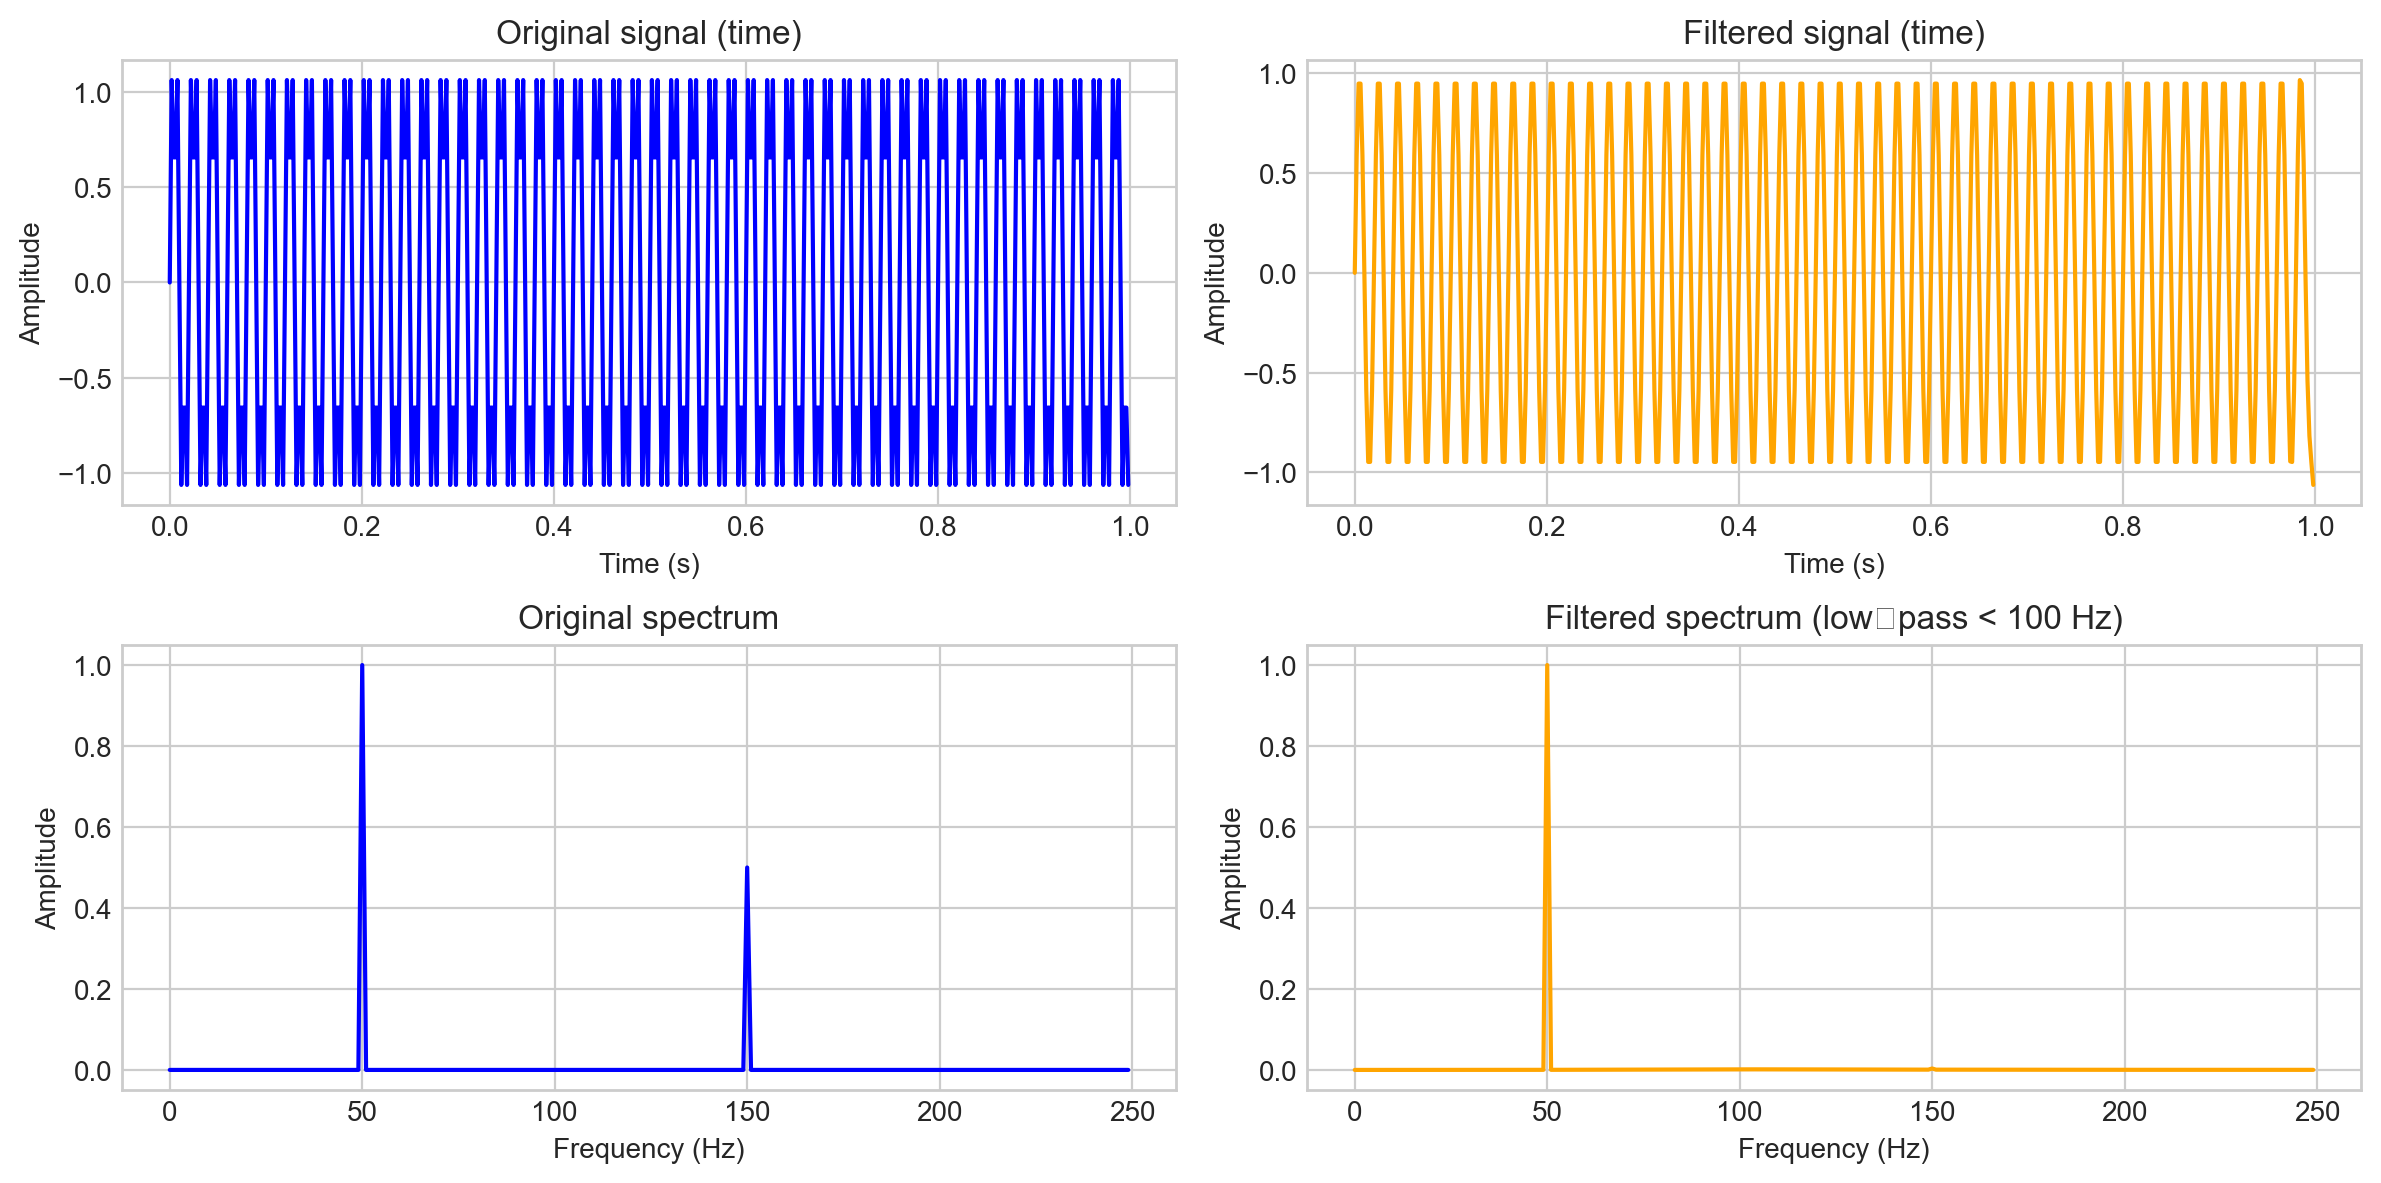

In [8]:
# --- Create composite signal ---
fs = 500                    # Sampling frequency (Hz)
t = np.arange(0, 1, 1/fs)   # 1 second

# Original signal: 50 Hz + 150 Hz
signal = np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 150 * t)

# --- Design low‑pass filter (cutoff = 100 Hz) ---
cutoff = 100                # Hz
b, a = butter(N=4, Wn=cutoff / (fs / 2), btype='low')

# Apply zero‑phase filter
filtered_signal = filtfilt(b, a, signal)

# --- Compute spectra using the global compute_fft function ---
xf, amp_original = compute_fft(signal, fs)
_, amp_filtered = compute_fft(filtered_signal, fs)

# --- Plot time domain and frequency domain ---
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# Time domain – original
axes[0, 0].plot(t, signal, color='blue')
axes[0, 0].set_title('Original signal (time)')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(True)

# Time domain – filtered
axes[0, 1].plot(t, filtered_signal, color='orange')
axes[0, 1].set_title('Filtered signal (time)')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].grid(True)

# Frequency domain – original
axes[1, 0].plot(xf, amp_original, color='blue')
axes[1, 0].set_title('Original spectrum')
axes[1, 0].set_xlabel('Frequency (Hz)')
axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].grid(True)

# Frequency domain – filtered
axes[1, 1].plot(xf, amp_filtered, color='orange')
axes[1, 1].set_title('Filtered spectrum (low‑pass < 100 Hz)')
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].set_ylabel('Amplitude')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

## 7. Time‑Frequency Analysis – Spectrogram

A spectrogram shows how the frequency content of a signal changes over time. We create a signal that switches from 50 Hz to 200 Hz at t = 1 s.

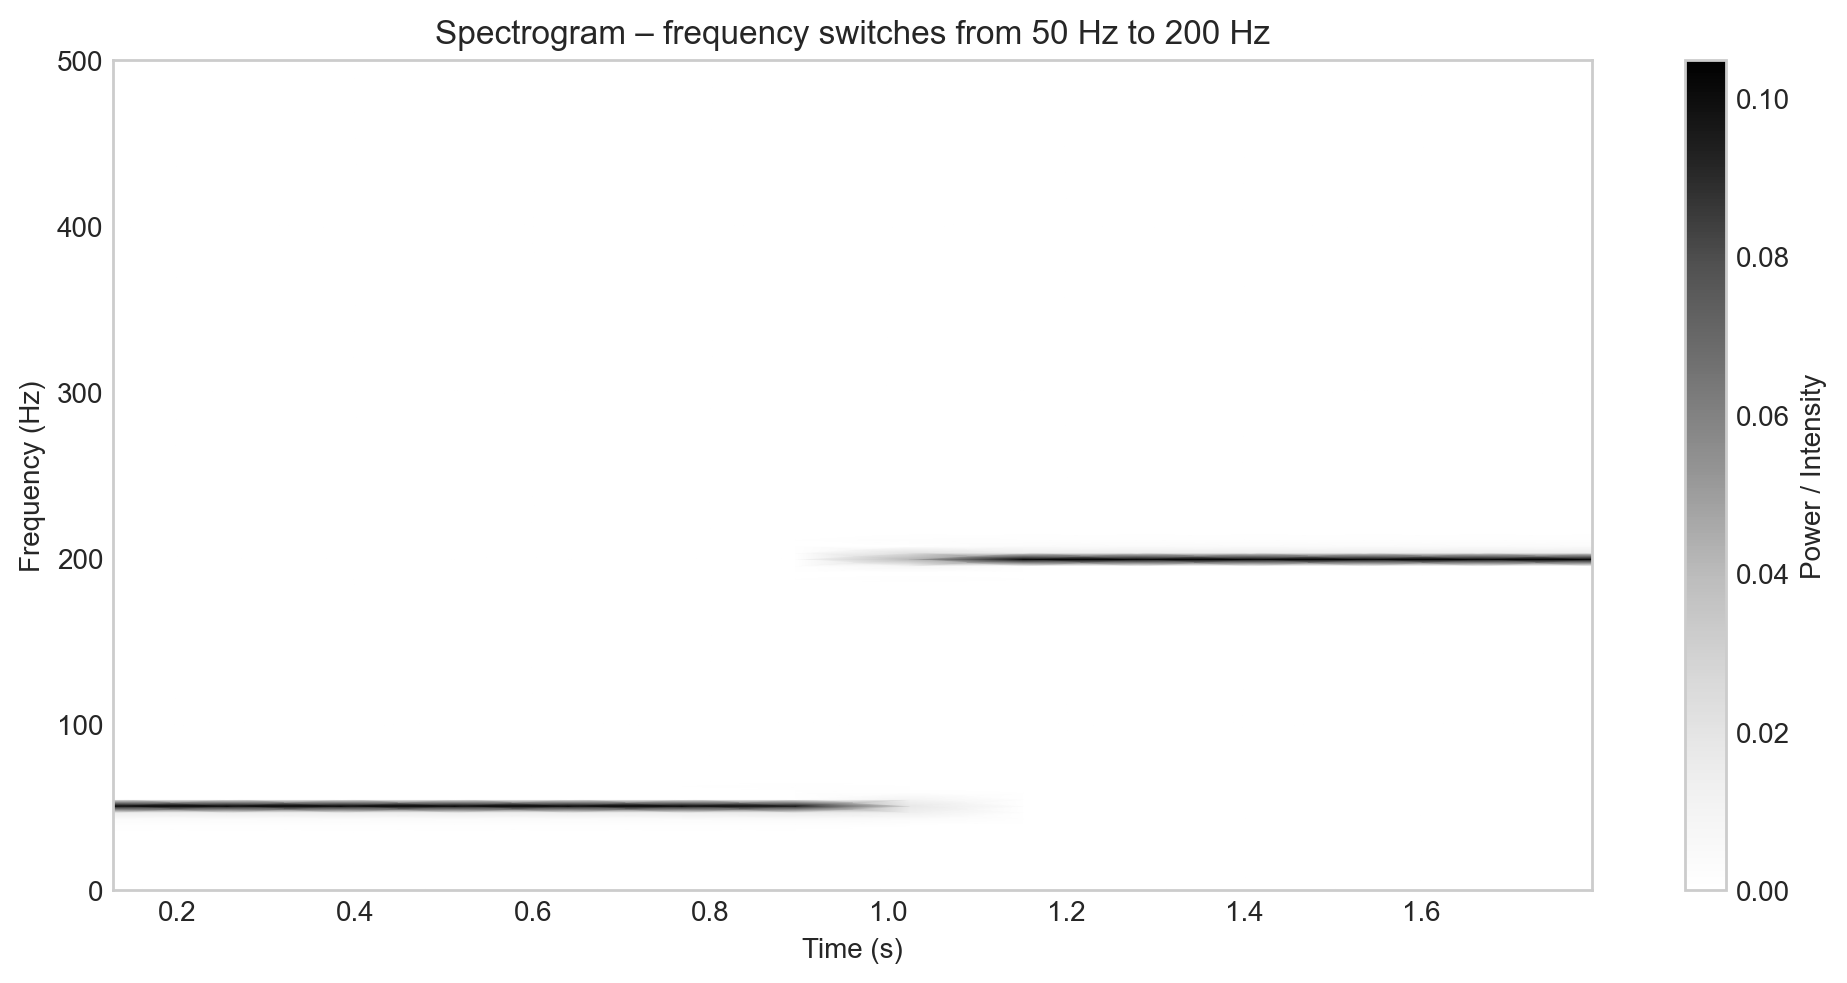

In [10]:
# Generate a signal with a frequency change
fs_spec = 1000
t_spec = np.linspace(0, 2, 2 * fs_spec, endpoint=False)
freq_switch = fs_spec  # index where frequency changes

signal_spec = np.concatenate([
    np.sin(2 * np.pi * 50 * t_spec[:freq_switch]),
    np.sin(2 * np.pi * 200 * t_spec[freq_switch:])
])

# Compute spectrogram
f_spec, t_spec_out, Sxx = spectrogram(signal_spec, fs_spec, nperseg=256, noverlap=128)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
mesh = ax.pcolormesh(t_spec_out, f_spec, Sxx, shading='gouraud')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('Spectrogram – frequency switches from 50 Hz to 200 Hz')
ax.set_ylim(0, 500)
ax.grid(True)
plt.colorbar(mesh, label='Power / Intensity')
plt.tight_layout()
plt.show()

## Summary

- **Sampling** must respect the Nyquist rate to avoid aliasing.
- **FFT** reveals the frequency components of a signal.
- **Filters** (low‑pass, band‑pass) can extract or suppress specific frequency bands.
- **Spectrograms** provide a time‑frequency view, essential for non‑stationary signals.
- These tools are foundational for audio, EEG, and many other signal‑processing tasks.

Next steps: try changing filter parameters, experiment with different window functions for the spectrogram, or apply these techniques to your own recordings.